In [19]:
import scvi

import scanpy as sc
import numpy as np
import anndata as ad

In [2]:
adata = sc.read_h5ad("../data/combosciplex.h5ad")

In [3]:
tmp = sc.pp.filter_genes(adata, min_cells=1000, inplace=False)[0]
adata[:, tmp]

View of AnnData object with n_obs × n_vars = 63378 × 12797
    obs: 'sample', 'Size_Factor', 'n.umi', 'RT_well', 'Drug1', 'Drug2', 'Well', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'condition', 'pathway1', 'pathway2', 'split', 'control', 'cell_type'
    var: 'id', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Drug1_colors', 'Drug2_colors', 'Well_colors', 'condition_colors', 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pathway1_colors', 'pathway2_colors', 'pathway_colors', 'pca', 'rank_genes_groups', 'split_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [4]:
sc.pp.filter_genes(adata, min_cells=1000)

adata.X = np.round(np.expm1(adata.X.toarray()))

In [5]:
scvi.model.SCVI.setup_anndata(adata)

In [58]:
model = scvi.model.SCVI(adata, n_hidden=1024, n_latent=10)
model.train(max_epochs=100)

/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/egor.antipov/miniconda3/envs/scaling-trans ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/egor.antipov/miniconda3/envs/scaling-trans ...
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-5f1dabc9-296d-5f69-a212-e7de5c7586cb]
/home/icb/egor.antipov/miniconda3/envs/scaling-tr

Training:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


In [66]:
model.save(dir_path="./scvi_models/1024_10")

In [67]:
latent = model.get_latent_representation()
latent.shape

(63378, 10)


In [69]:
adata.obsm["latent_10"] = latent

In [70]:
scvi.model.SCVI.setup_anndata(adata)

model = scvi.model.SCVI(adata, n_hidden=1024, n_latent=30)
model.train(max_epochs=100)

/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/egor.antipov/miniconda3/envs/scaling-trans ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/egor.antipov/miniconda3/envs/scaling-trans ...
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-5f1dabc9-296d-5f69-a212-e7de5c7586cb]
/home/icb/egor.antipov/miniconda3/envs/scaling-tr

Training:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


In [71]:
model.save(dir_path="./scvi_models/1024_30")

In [72]:
latent = model.get_latent_representation()
latent.shape

(63378, 30)

In [73]:
adata.obsm["latent_30"] = latent

In [74]:
scvi.model.SCVI.setup_anndata(adata)

model = scvi.model.SCVI(adata, n_hidden=1024, n_latent=50)
model.train(max_epochs=100)

/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/egor.antipov/miniconda3/envs/scaling-trans ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/egor.antipov/miniconda3/envs/scaling-trans ...
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-5f1dabc9-296d-5f69-a212-e7de5c7586cb]
/home/icb/egor.antipov/miniconda3/envs/scaling-tr

Training:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


In [75]:
model.save(dir_path="./scvi_models/1024_50")

In [76]:
latent = model.get_latent_representation()
latent.shape

(63378, 50)

In [77]:
adata.obsm["latent_50"] = latent

In [78]:
adata.write_h5ad("./data/combosciplex_with_latent.h5ad")

**Test models**

In [23]:
adata = sc.read_h5ad("../data/combosciplex.h5ad")
sc.pp.filter_genes(adata, min_cells=1000)
adata.X = np.round(np.expm1(adata.X.toarray()))

In [32]:
model = scvi.model.SCVI.load("./scvi_models/1024_50/", adata=adata)

INFO     File ./scvi_models/1024_50/model.pt already downloaded                                                    


/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/egor.antipov/miniconda3/envs/scaling-trans ...


In [33]:
recon = model.get_normalized_expression(adata, return_numpy=True)
orig = adata.X

In [34]:
obs = {"type": ["recon" for _ in range(recon.shape[0])] + ["orig" for _ in range(orig.shape[0])]}
combined = ad.AnnData(X=np.concatenate([recon, orig]), obs=obs)
print("Created")
sc.pp.pca(combined, n_comps=50)
print("PCA")
sc.pp.neighbors(combined)
print("Neighbors")
sc.tl.umap(combined)
print("Finished")

Created
PCA
Neighbors
Finished


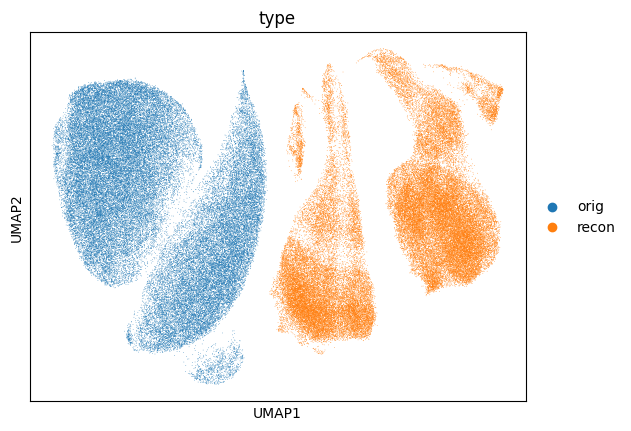

In [35]:
# 50 dims
sc.pl.umap(combined, color="type")

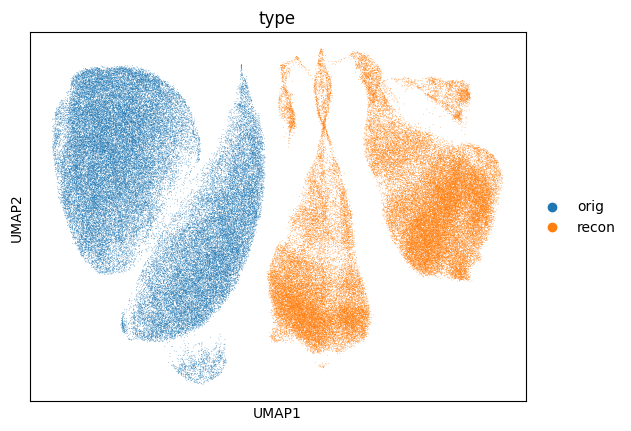

In [31]:
# 30 dims
sc.pl.umap(combined, color="type")

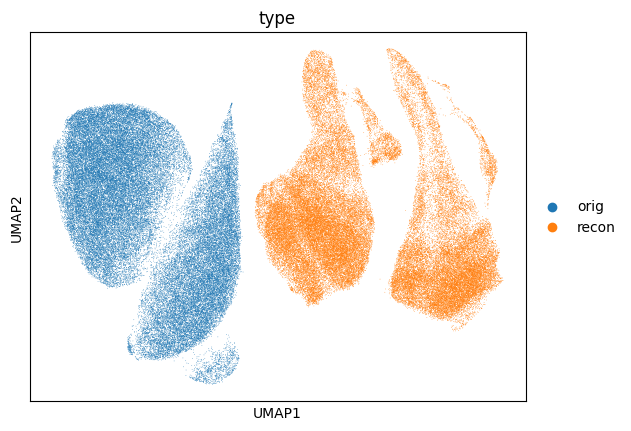

In [27]:
# 10 dims
sc.pl.umap(combined, color="type")